In [50]:
import argparse
import os
import pickle
import sys
import typing
import copy

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    modeling_outputs
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
sys.path.append("../config")
import experiment_config

In [3]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
import interp_utils

In [4]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

# Investigating whether biologically redundant sites (highly conserved regions/co-varying sites) are re-used for computation

# Load $\text{ESM}_{\text{coronaviridae}}$ rather than CovFit model

In [5]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/models/model_ESM2_coronaviridae/config.json"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = "./covfit_stuff/models/model_ESM2_coronaviridae/pytorch_model.bin"
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
CONTEXT_LEN = 1024
device = experiment_config.device

torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")

In [6]:
esm_config = None
with open (CONF_DIR, "r") as f:
    conf_data = json.load(f)
    esm_config = EsmConfig(**conf_data)
esm_config.token_dropout = False
esm_config.model_name = MODEL_NAME

In [7]:
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"

# Get coronaviridae ESM
# Optionally, then switch to final LoRA finetuned fitness ESM
esm_disp = EsmForMaskedLM(esm_config).to(device)
esm_disp_state_dict = torch.load(MODEL_PATH)
# removing fixed position embedding
del esm_disp_state_dict["esm.embeddings.position_embeddings.weight"]
del esm_disp_state_dict["esm.embeddings.position_ids"]
print(esm_disp.load_state_dict(esm_disp_state_dict))

<All keys matched successfully>


In [8]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [9]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [10]:
tokenizer = EsmTokenizer(**tokenizer_config)

# Load hooked transformer version of $\text{ESM}_{\text{coronaviridae}}$

In [11]:
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [12]:
hooked_esm_config = interp_utils.get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)

In [13]:
print(hooked_esm.load_state_dict(interp_utils.get_hooked_state_dict(esm_disp.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [14]:
def get_logit_coronaviridae(output, lm_head=esm_disp.lm_head):
    """
    output: Tensor[batch, seq_len, d_model], output of hooked_esm when run on a tokenized seq.

    returns: Tensor[batch, seq_len, vocab], output matching what coronaviridae would output
    """
    return lm_head(output)

def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

In [15]:
hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = interp_utils.add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [16]:
logit_id = original_task_id_infos["fitness_USA"]

In [17]:
# clean up memory
torch.cuda.empty_cache()

In [75]:
# 1. Define the wrapper class
class HFHookedTransformerWrapper(nn.Module):
    def __init__(self, hooked_model: HookedTransformer, lm_head=esm_disp.lm_head):
        super().__init__()
        self.model = hooked_model
        # Trainer checks configuration attributes; forward this if needed
        self.config = hooked_model.cfg 
        self.lm_head = lm_head

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # By setting return_type="loss", HookedTransformer calculates cross-entropy loss internally
        # if labels (tokens) are provided.
        if labels is not None:
            logits = self.lm_head(self.model(input_ids))
            loss = nn.functional.cross_entropy(logits.view(-1, logits.shape[-1]), labels.view(-1))
        else:
            logits = self.lm_head(self.model(input_ids))
            loss = None

        return modeling_outputs.CausalLMOutputWithPast(
            loss=loss,
            logits=logits,
        )

In [76]:
wrapped_transformer = HFHookedTransformerWrapper(hooked_model=hooked_esm)

# Perplexities

In [77]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [78]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [79]:
pathogen_perplexities = dict()

In [80]:
def eval_model(model):
    virus_dsets = ["sars_cov_2_spike", "sars_cov_2_spike_africa", "sars_cov_2_spike_asia", "sars_cov_2_spike_europe", "sars_cov_2_spike_north_america", "sars_cov_2_spike_oceania", "sars_cov_2_spike_south_america"]
    # for pathogen_name in ["sars_cov_2_spike", "cov_229e_s1"]:
    for pathogen_name in virus_dsets:
        fasta_file = f"../data/pathogen/{pathogen_name}/alignment.fasta"
        data = load_sequences(fasta_file)
        sequence_names, sequences = list(zip(*list(data.items())))
        uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 
    
    
        # identical code to how it's compute_node_embeddings.py
        protein_coords = config["pathogens"][pathogen_name]["protein_coords"]
        cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
        cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming
    
        # create dataset
        eval_dict = {"input_ids":list(cut_seqs)}
    
        eval_dset = Dataset.from_dict(eval_dict)
    
        column_names = eval_dset.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
        eval_dataset = eval_dset.map( 
            tokenizer_for_map,
            batched=True,
            num_proc=8,
            remove_columns=column_names,
        )
    
        # evaluate ESM-2 model on dataset 
        evaluator = Trainer(
          model=wrapped_transformer,
          data_collator=data_collator,
          eval_dataset=eval_dataset,
        )
        # evaluator = Trainer(
        #   model=esm_disp,
        #   data_collator=data_collator,
        #   eval_dataset=eval_dataset,
        # )
        eval_results = evaluator.evaluate()
        pathogen_perplexities[pathogen_name] = math.exp(eval_results['eval_loss'])
        print(f"Pathogen: {pathogen_name}\nESM-2 Perplexity: {pathogen_perplexities[pathogen_name]:.4f}\n")

    return pathogen_perplexities

Map (num_proc=8): 100%|███████████████████████████████████████████████████████████████████| 1699/1699 [00:01<00:00, 1258.48 examples/s]


{'eval_loss': 0.9433563351631165, 'eval_model_preparation_time': 0.0059, 'eval_runtime': 11.8711, 'eval_samples_per_second': 143.121, 'eval_steps_per_second': 17.943}
Pathogen: sars_cov_2_spike
ESM-2 Perplexity: 2.5686



Map (num_proc=8): 100%|██████████████████████████████████████████████████████████████████████| 894/894 [00:01<00:00, 854.12 examples/s]


{'eval_loss': 0.7998153567314148, 'eval_model_preparation_time': 0.006, 'eval_runtime': 6.2472, 'eval_samples_per_second': 143.103, 'eval_steps_per_second': 17.928}
Pathogen: sars_cov_2_spike_africa
ESM-2 Perplexity: 2.2251



Map (num_proc=8): 100%|████████████████████████████████████████████████████████████████████| 1204/1204 [00:01<00:00, 991.75 examples/s]


...

{'eval_loss': 0.9202161431312561, 'eval_model_preparation_time': 0.0058, 'eval_runtime': 10.5227, 'eval_samples_per_second': 143.214, 'eval_steps_per_second': 17.961}
Pathogen: sars_cov_2_spike_north_america
ESM-2 Perplexity: 2.5098



Map (num_proc=8): 100%|██████████████████████████████████████████████████████████████████████| 582/582 [00:00<00:00, 611.93 examples/s]


{'eval_loss': 0.8143405914306641, 'eval_model_preparation_time': 0.0062, 'eval_runtime': 4.0909, 'eval_samples_per_second': 142.266, 'eval_steps_per_second': 17.844}
Pathogen: sars_cov_2_spike_oceania
ESM-2 Perplexity: 2.2577



Map (num_proc=8): 100%|████████████████████████████████████████████████████████████████████| 1074/1074 [00:01<00:00, 920.04 examples/s]


{'eval_loss': 0.8439366221427917, 'eval_model_preparation_time': 0.0059, 'eval_runtime': 7.5352, 'eval_samples_per_second': 142.531, 'eval_steps_per_second': 17.916}
Pathogen: sars_cov_2_spike_south_america
ESM-2 Perplexity: 2.3255



In [81]:
uniref50_ds = load_dataset("fredzzp/Uniref50", split="test")
column_names = uniref50_ds.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
uniref_tokenizer_map = functools.partial(tokenizer_for_map, seq_key="sequence")
uniref_dataset = uniref50_ds.map( 
        uniref_tokenizer_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)
os.environ["WANDB_DISABLED"] = "true"

# evaluate ESM-2 model on uniref50 
# evaluator = Trainer(
#   model=esm_disp,
#   data_collator=data_collator,
#   eval_dataset=uniref_dataset[:800]["input_ids"],
# )
evaluator = Trainer(
  model=wrapped_transformer,
  data_collator=data_collator,
  eval_dataset=uniref_dataset[:800]["input_ids"],
)
uniref_results = evaluator.evaluate()
pathogen_perplexities["uniref50"] = math.exp(uniref_results['eval_loss'])
print(f"Uniref50 ESM-2 Perplexity: {pathogen_perplexities['uniref50']:.4f}\n")

Map (num_proc=8): 100%|█████████████████████████████████████████████████████████████████| 48941/48941 [00:15<00:00, 3091.11 examples/s]


{'eval_loss': 2.0655150413513184, 'eval_model_preparation_time': 0.0067, 'eval_runtime': 5.4357, 'eval_samples_per_second': 147.175, 'eval_steps_per_second': 18.397}
Uniref50 ESM-2 Perplexity: 7.8894



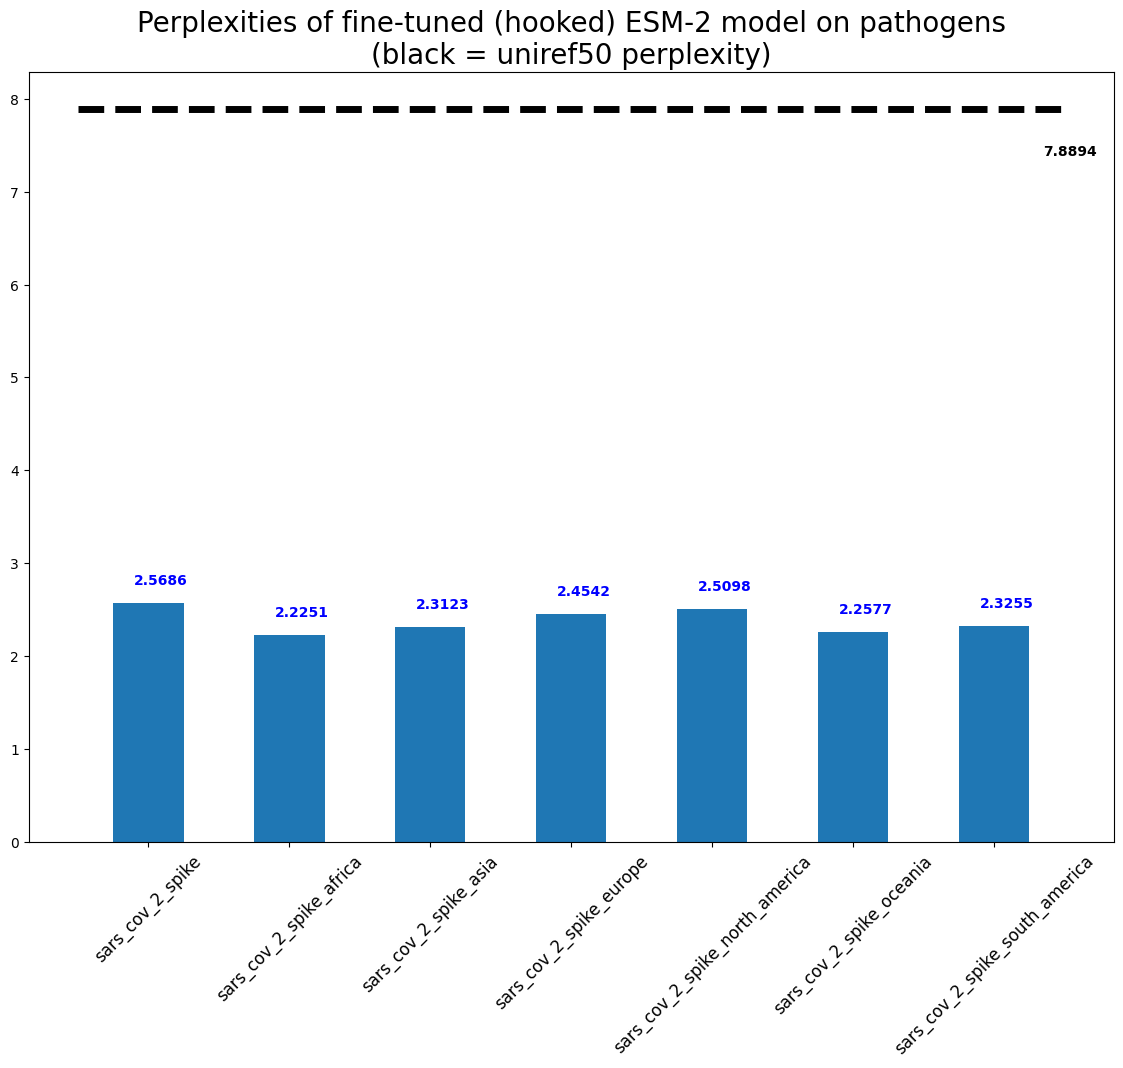

In [82]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("Perplexities of fine-tuned (hooked) ESM-2 model on pathogens\n(black = uniref50 perplexity)",fontsize=20)
ax.bar(x=virus_dsets, height=[pathogen_perplexities[p] for p in virus_dsets], width=0.5)
ax.tick_params("x", rotation=45, labelsize=12)
ax.plot([-0.5,len(virus_dsets) - .5], [pathogen_perplexities["uniref50"] for _ in range(2)], linestyle="dashed", color="black", linewidth=5)
for i,v in enumerate([pathogen_perplexities[p] for p in virus_dsets]):
    ax.text(i-0.1, v+0.2, f"{v:.4f}", color='blue', fontweight='bold')

ax.text(len(virus_dsets) - 0.65, pathogen_perplexities["uniref50"] - .5, f"{pathogen_perplexities['uniref50']:.4f}", color="black", fontweight="bold")
fig.show()

# Load data

In [18]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [19]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [20]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [21]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4533
torch.Size([4533, 1024])


# Linear probe

In [40]:
esm_disp = esm_disp.eval()

In [22]:
COVARYING_SITE_SETS = [
    [373,375,655,679,764,796,954,969],
    [50,127,245,264,332,356,450,481,621,939]
]

In [23]:
rand_seq_idx = torch.multinomial(torch.ones(len(all_uniq_seqs),),num_samples=80).sort().values
rand_subset_seqs = [all_uniq_seqs[i] for i in rand_seq_idx]

tokenized_data = tokenizer(rand_subset_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
rand_seqs = tokenized_data["input_ids"].to(device)
rand_seqs_attn_mask = tokenized_data["attention_mask"].to(device)

In [41]:
outputs = esm_disp(rand_seqs[:1], attention_mask = rand_seqs_attn_mask[:1], output_hidden_states=True)
reg_esm_hs = outputs.hidden_states
hooked_toks, cache = hooked_esm.run_with_cache(rand_seqs[:1])

In [27]:
_, rand_seqs_cache = hooked_esm.run_with_cache(rand_seqs, names_filter=lambda name: name.endswith("_out"))
# _, rand_seqs_cache = hooked_esm.run_with_cache(rand_seqs[:1])
del _
torch.cuda.empty_cache()

In [28]:
rand_seqs_cache["blocks.0.hook_attn_out"].shape

torch.Size([80, 1024, 1280])

In [29]:
# train linear probes for each site at each layer
layer = 10